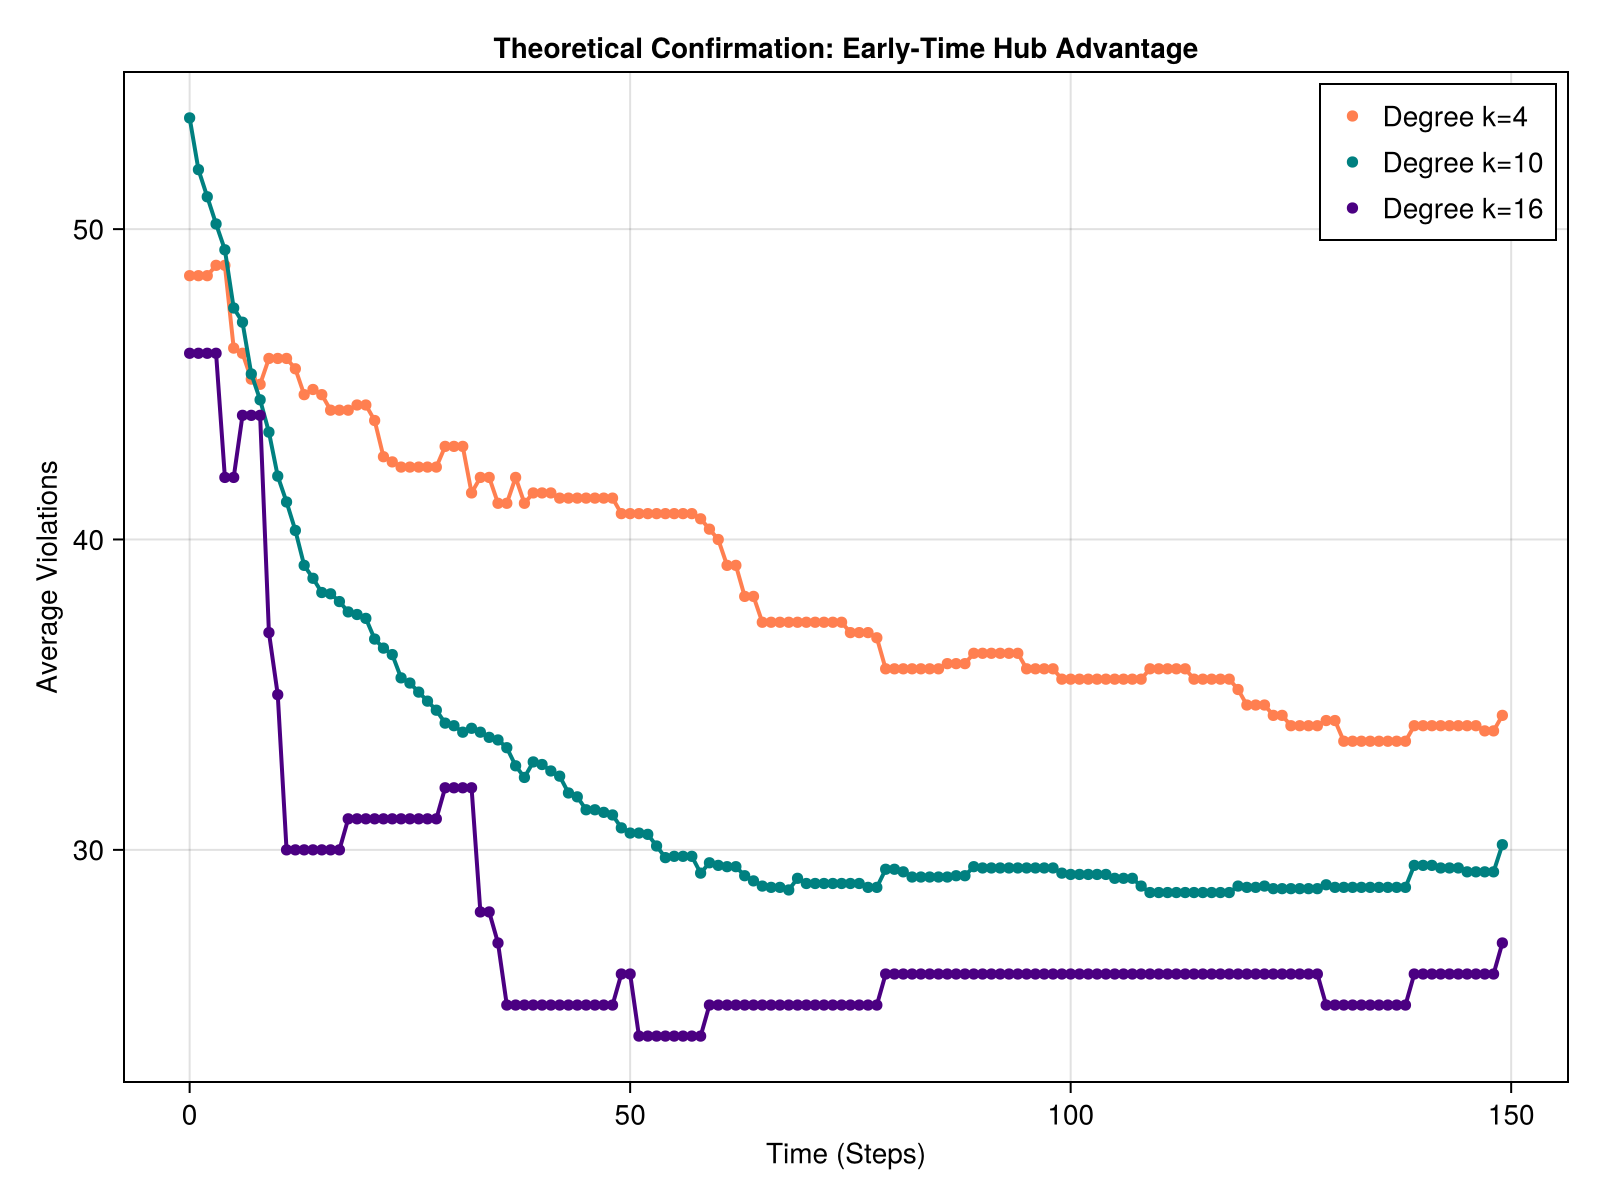

In [1]:
using CSV
using DataFrames
using CairoMakie

# Load the time-series matrix generated by the simulation
df = CSV.read("degree_divergence.csv", DataFrame)

# Generate a scatter plot to observe the linear separation
fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Time (Steps)", 
    ylabel = "Average Violations",
    title = "Theoretical Confirmation: Early-Time Hub Advantage"
)

# Select a peripheral, intermediate, and hub degree to visualize the divergence
target_degrees = ["4", "10", "16"]
palette = [:coral, :teal, :indigo]

for (i, k_str) in enumerate(target_degrees)
    if hasproperty(df, k_str)
        # Plot both scatter points and lines to track the step-by-step trajectory
        scatter!(ax, df.step, df[!, k_str], label = "Degree k=$k_str", color = palette[i], markersize = 8)
        lines!(ax, df.step, df[!, k_str], color = palette[i], linewidth = 2)
    end
end

axislegend(ax, position = :rt)
fig

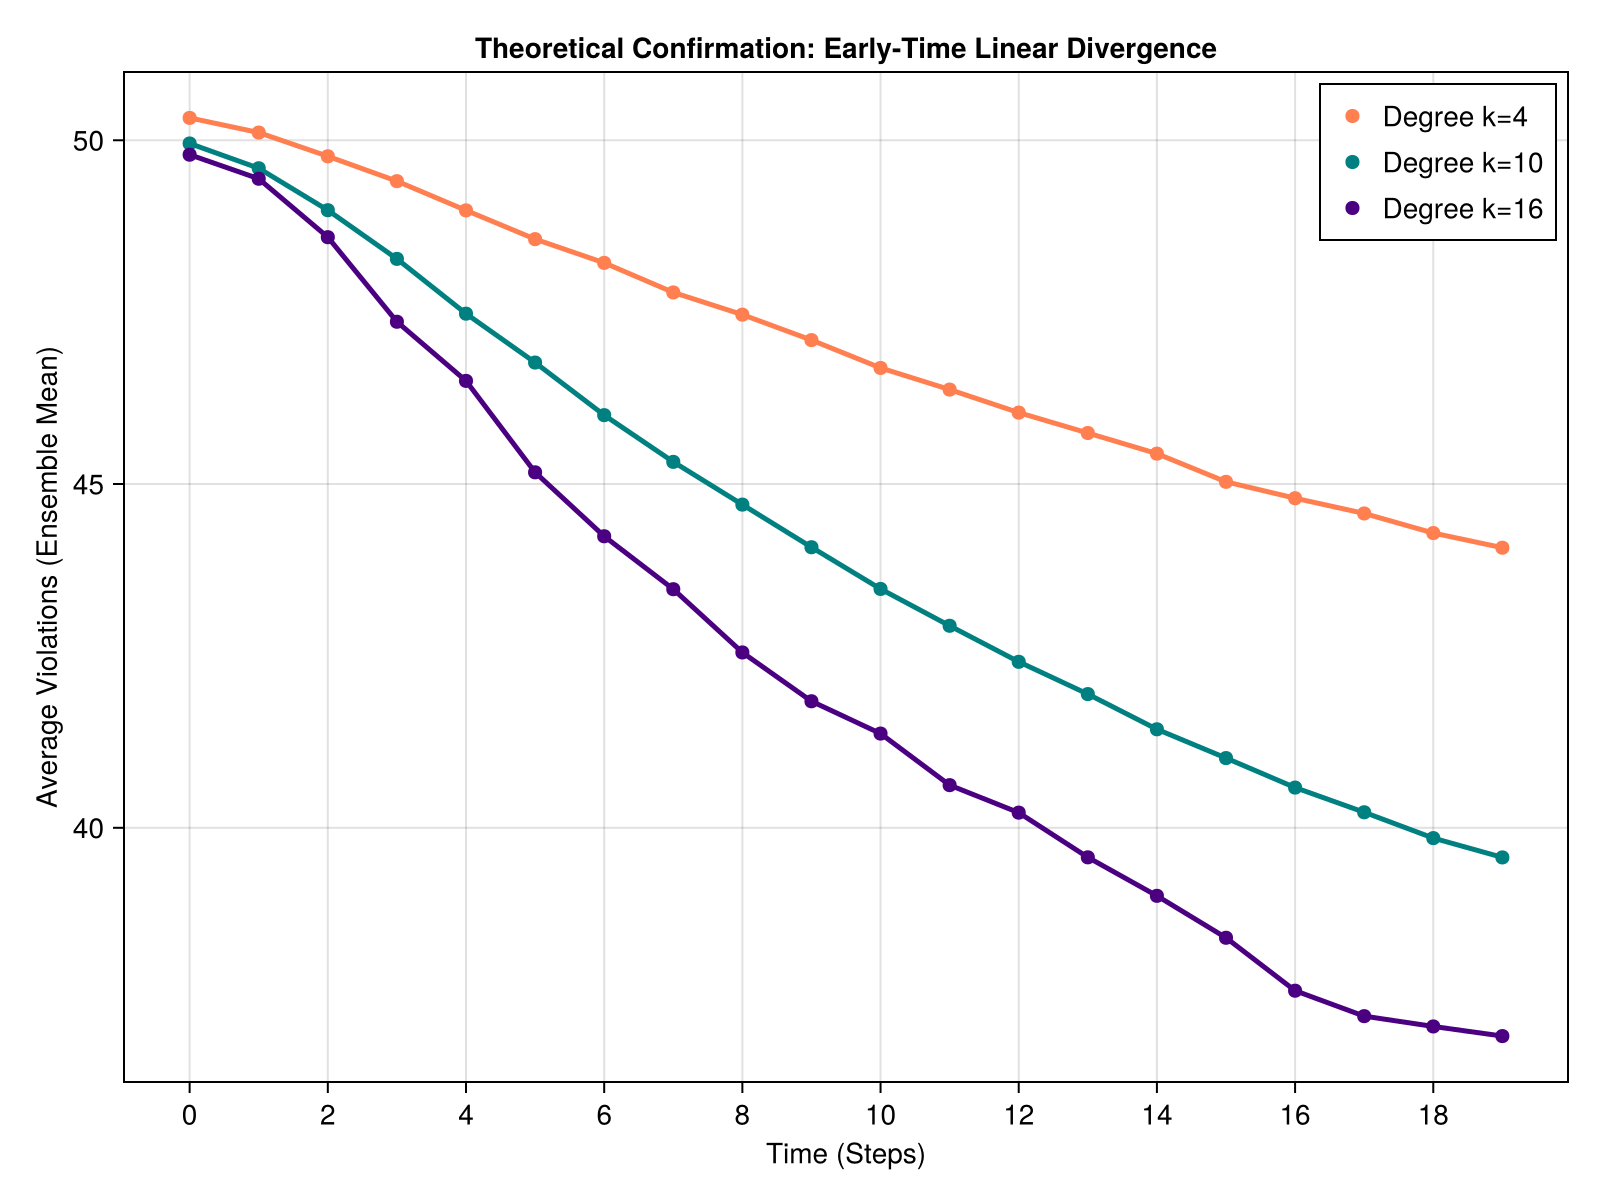

In [7]:
using CSV
using DataFrames
using CairoMakie

# Load the smoothed ensemble time-series matrix
df = CSV.read("ensemble_degree_divergence.csv", DataFrame)

# Generate a scatter plot to observe the linear separation
fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Time (Steps)", 
    ylabel = "Average Violations (Ensemble Mean)",
    title = "Theoretical Confirmation: Early-Time Linear Divergence",
    xticks = 0:2:20 # Clean up the x-axis for the shortened timeframe
)

# Select a peripheral, intermediate, and hub degree
target_degrees = ["4", "10", "16"]
palette = [:coral, :teal, :indigo]

for (i, k_str) in enumerate(target_degrees)
    if hasproperty(df, k_str)
        # Plot markers and lines
        scatter!(ax, df.step, df[!, k_str], label = "Degree k=$k_str", color = palette[i], markersize = 10)
        lines!(ax, df.step, df[!, k_str], color = palette[i], linewidth = 2.5)
    end
end

axislegend(ax, position = :rt)
fig